In [1]:
import emcee
import numpy as np
import matplotlib.pyplot as plt
import pickle
import corner

In [2]:
import pandas as pd
import tensorflow as tf

2026-01-13 22:29:51.763678: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-01-13 22:29:54.983807: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


In [3]:
from scipy.stats import gaussian_kde


In [4]:
# define your plot style

best_style = {
    "font.family": "sans-serif",
    "mathtext.fontset": "custom",
    "mathtext.rm": "TeX Gyre Heros",
    "mathtext.bf": "TeX Gyre Heros:bold",
    "mathtext.sf": "TeX Gyre Heros",
    "mathtext.it": "TeX Gyre Heros:italic",
    "mathtext.tt": "TeX Gyre Heros",
    "mathtext.cal": "TeX Gyre Heros",
    "mathtext.default": "regular",
    "figure.figsize": (10.0, 10.0),
    "font.size": 26,
    "axes.labelsize": "medium",
    "axes.unicode_minus": False,
    "xtick.labelsize": "small",
    "ytick.labelsize": "small",
    "legend.fontsize": "small",
    "legend.handlelength": 1.5,
    "legend.borderpad": 0.5,
    "xtick.direction": "in",
    "xtick.major.size": 12,
    "xtick.minor.size": 6,
    "xtick.major.pad": 6,
    "xtick.top": True,
    "xtick.major.top": True,
    "xtick.major.bottom": True,
    "xtick.minor.top": True,
    "xtick.minor.bottom": True,
    "xtick.minor.visible": True,
    "ytick.direction": "in",
    "ytick.major.size": 12,
    "ytick.minor.size": 6.0,
    "ytick.right": True,
    "ytick.major.left": True,
    "ytick.major.right": True,
    "ytick.minor.left": True,
    "ytick.minor.right": True,
    "ytick.minor.visible": True,
    "grid.alpha": 0.8,
    "grid.linestyle": ":",
    "axes.linewidth": 2,
    "savefig.transparent": False,
}
plt.style.use(best_style)
cols = ["#5790fc", "#f89c20", "#e42536", "#964a8b", "#9c9ca1", "#7a21dd"]
#set cols as the matplotlib default color cycle
plt.rcParams['axes.prop_cycle'] = plt.cycler(color=cols)

In [5]:
model_name = "entire_region_narrowprior"
model_path = '/deepskieslab/stronglensing/hsbi/models/'
model = tf.keras.models.load_model(model_path + model_name + '.keras')

2026-01-13 22:30:00.450644: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:995] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2026-01-13 22:30:01.167070: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:995] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2026-01-13 22:30:01.167474: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:995] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysf

In [6]:
datadir = "region2_narrowprior"

image_dir = f'/deepskieslab/stronglensing/hsbi/datasets/test_data/{datadir}/data_0'
images = np.load(image_dir + '/CONFIGURATION_1_images.npy', allow_pickle=True)
metadata = pd.read_csv(image_dir + '/CONFIGURATION_1_metadata.csv')

In [7]:
w_column_name = "w0-g" # Dark energy equation-of-state parameter 
om_column_name = 'Om0-g'
zl_column_name = 'PLANE_1-REDSHIFT-g'
zs_column_name = 'PLANE_2-REDSHIFT-g'
v_column_name = 'PLANE_1-OBJECT_1-MASS_PROFILE_1-sigma_v-g'

In [8]:
n_images = 5
images = images[0: n_images]
metadata = metadata[0: n_images]
images = np.einsum('lkij->lijk', images)
# add channel dimension
print(images.shape)

aparms = metadata[[zl_column_name,zs_column_name,v_column_name]].to_numpy().astype(np.float32)

(5, 32, 32, 1)


In [9]:
edge_size = images.shape[1]
images = edge_size * edge_size * (images / np.sum(images, axis=(1, 2), keepdims=True))
images = images.reshape(images.shape[0], -1)
images = images.reshape(images.shape[0], edge_size, edge_size, 1)

In [10]:
# return true values
true_w = metadata[w_column_name].unique()[0]
true_om = metadata[om_column_name].unique()[0]

print(true_w, true_om)

-0.9895467391672544 0.3289012922760826


## MCMC

In [11]:
def get_logr_mcmc(model, images, aparam, sample_theta):
    ''''
    Function to predict the log likelihood-to-evidence ratio (logr) of all the test data at a time

    Input:
    model: The trained model 
    images: test images
    sample_theta: a list of theta values to compute logr for

    Output:
    log r 
    '''
    theta_array = np.array([sample_theta]*images.shape[0])
    output = model.predict([images, aparam, theta_array], verbose=0).flatten()
    return output

def log_prior(theta, w_low=-1.5, w_high=-0.5, om_low=0.1, om_high=0.5):
    """
    prior for w, om
    """
    w, om = theta
    if w_low < w < w_high and om_low < om < om_high:
        return 0.0
    return -np.inf

def log_likelihood(theta, data, aparam, w_low, w_high, om_low, om_high, model, calibrate):
    """
    Calculate the log likelihood + log prior
    """
    lp = log_prior(theta, w_low, w_high, om_low, om_high)
    if not np.isfinite(lp):
        return -np.inf
    logr_array = get_logr_mcmc(model, data, aparam, theta)
    if calibrate:
        alpha = 0.175255
        beta = 0.11896
        ll = alpha*np.sum(logr_array) + beta
    else:
        ll = np.sum(logr_array)
    return lp + ll

In [12]:
initial_w=-1.0
initial_om=0.3
walkers=5
nsteps=1000
nburn=200

ommin = 0.1
ommax = 0.9
wmin = -1.8
wmax = -0.4

In [13]:
# # without calibration
# pos = np.array([initial_w, initial_om]) + np.array([initial_w, initial_om]) * 1e-3 * np.random.randn(walkers, 2)
# nwalkers, ndim = pos.shape

# calibrate = False
# flat_samples_list = []

# for i in range(n_images):
#     data = images[i: i+1]
#     aparam = aparms[i: i+1]

#     sampler = emcee.EnsembleSampler(nwalkers, ndim, log_likelihood, args=(data, aparam, wmin, wmax, ommin, ommax, model, calibrate))
#     print("Running first burn-in...")
#     pos, lp, _ = sampler.run_mcmc(pos, nburn, progress=True)
#     print('Max lp @', pos[np.argmax(lp)])

#     print("Running production...")
#     pos = pos[np.argmax(lp)] + 1e-4 * np.random.randn(nwalkers, ndim)
#     sampler.reset()
#     pos, lp, _ = sampler.run_mcmc(pos, nsteps, progress=True)
#     print('Max lp @', pos[np.argmax(lp)])

#     flat_samples = sampler.get_chain(discard=int(nsteps / 4), flat=True)
#     flat_samples_list.append(flat_samples)

# flat_samples_nocalibrate = np.vstack(flat_samples_list)

In [ ]:
# # save the flat samples without calibration
# with open('flat_samples_5images_nocalibrate.pkl', 'wb') as f:
#     pickle.dump(flat_samples_nocalibrate, f)

In [14]:
# # with calibration
# calibrate = True
# flat_samples_list_calibrate = []
# pos = np.array([initial_w, initial_om]) + np.array([initial_w, initial_om]) * 1e-3 * np.random.randn(walkers, 2)
# nwalkers, ndim = pos.shape

# for i in range(n_images):
#     data = images[i: i+1]
#     aparam = aparms[i: i+1]

#     sampler = emcee.EnsembleSampler(nwalkers, ndim, log_likelihood, args=(data, aparam, wmin, wmax, ommin, ommax, model, calibrate))
#     print("Running first burn-in...")
#     pos, lp, _ = sampler.run_mcmc(pos, nburn, progress=True)
#     print('Max lp @', pos[np.argmax(lp)])

#     print("Running production...")
#     pos = pos[np.argmax(lp)] + 1e-4 * np.random.randn(nwalkers, ndim)
#     sampler.reset()
#     pos, lp, _ = sampler.run_mcmc(pos, nsteps, progress=True)
#     print('Max lp @', pos[np.argmax(lp)])

#     flat_samples = sampler.get_chain(discard=int(nsteps / 4), flat=True)
#     flat_samples_list_calibrate.append(flat_samples)

# flat_samples_calibrate = np.vstack(flat_samples_list_calibrate)

In [ ]:
# # save the flat samples with calibration
# with open('flat_samples_5images_calibrate.pkl', 'wb') as f:
#     pickle.dump(flat_samples_calibrate, f)

In [32]:
# Load the pickle file
with open('flat_samples_5images_nocalibrate.pkl', 'rb') as f:
    flat_samples_nocalibrate = pickle.load(f)

with open('flat_samples_5images_calibrate.pkl', 'rb') as f:
    flat_samples_calibrate = pickle.load(f)

In [26]:
flat_samples_nocalibrate.shape

(18750, 2)

In [33]:
n_samples_per_image = flat_samples_nocalibrate.shape[0] // n_images  # 3750
flat_samples_list = np.split(flat_samples_nocalibrate, n_images)

In [34]:
n_samples_per_image = flat_samples_calibrate.shape[0] // n_images  # 3750
flat_samples_list_calibrate = np.split(flat_samples_calibrate, n_images)

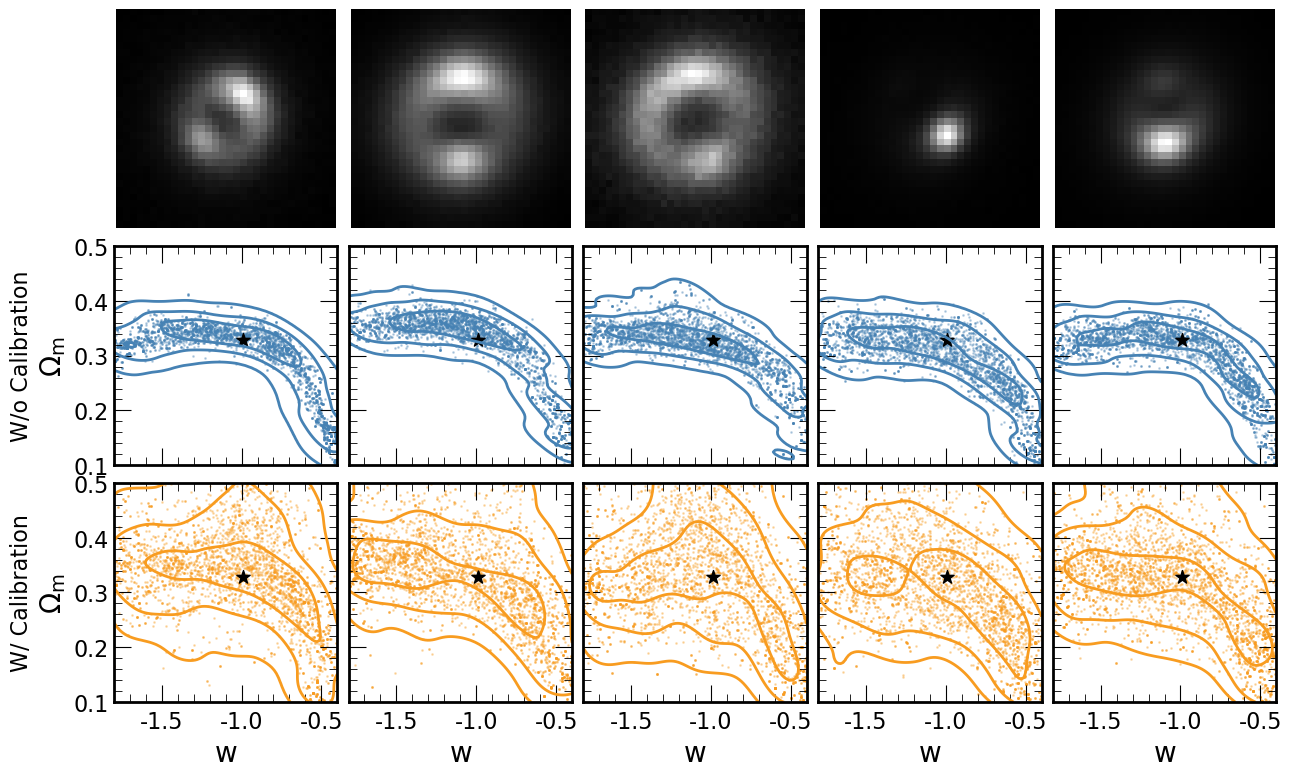

In [40]:
# plot normalized images and the corresponding posterior contours in a 5 column 3 rows  
# plot without calibration in second row and with calibration in third row
x_min = -1.8
x_max = -0.4
y_min = 0.1
# y_max = 0.45
y_max = 0.5
fig, axes = plt.subplots(3, n_images, figsize=(15, 9))
for i in range(n_images):   
    axes[0, i].imshow(images[i, :, :, 0], cmap='gray')
    axes[0, i].axis('off')

    # plot without calibration
    flat_samples = flat_samples_list[i]
    x = flat_samples[:, 0]
    y = flat_samples[:, 1]
    values = np.vstack([x, y])
    kde = gaussian_kde(values)
    
    # Evaluate grid
    nbins = 100
    xgrid = np.linspace(x_min, x_max, nbins)
    ygrid = np.linspace(y_min, y_max, nbins)
    X, Y = np.meshgrid(xgrid, ygrid)
    positions = np.vstack([X.ravel(), Y.ravel()])
    Z = kde(positions).reshape(X.shape)
    
    # Compute contour levels for 1,2,3 sigma
    def get_levels(Z, sigmas=[1,2,3]):
        Z_flat = Z.flatten()
        Z_sorted = np.sort(Z_flat)[::-1]
        cumsum = np.cumsum(Z_sorted)
        cumsum /= cumsum[-1]
        levels = []
        for s in sigmas:
            frac = 1 - np.exp(-0.5 * s**2)
            idx = np.searchsorted(cumsum, frac)
            levels.append(Z_sorted[idx])
        return levels

    levels = get_levels(Z, [1,2,3])
    levels = np.sort(levels)  # Ensure levels are increasing

    # Plot filled density
    axes[1, i].scatter(x, y, s=4, alpha=0.3, color='steelblue', marker='.')
    # Plot 1,2,3 sigma contours
    axes[1, i].contour(X, Y, Z, levels=levels, colors='steelblue', linewidths=2)
    axes[1, i].scatter(true_w, true_om, color="k", s=100, marker="*")
    axes[1, i].set_xlabel(r"$w$", fontsize=20)
    axes[1, i].set_ylabel(r"$\Omega_m$", fontsize=20)
    axes[1, i].tick_params(axis='both', labelsize=16)
    # set x and y limits to x_min, x_max and y_min, y_max
    axes[1, i].set_xlim(x_min, x_max)
    axes[1, i].set_ylim(y_min, y_max) 

    # remove the x ticks for plots in the second row 
    axes[1, i].set_xticklabels([])
    axes[1, i].set_xlabel('')


    # plot with calibration
    flat_samples = flat_samples_list_calibrate[i]
    x = flat_samples[:, 0]
    y = flat_samples[:, 1]
    values = np.vstack([x, y])
    kde = gaussian_kde(values)  
    # Evaluate grid
    nbins = 100
    xgrid = np.linspace(x_min, x_max, nbins)
    ygrid = np.linspace(y_min, y_max, nbins)
    X, Y = np.meshgrid(xgrid, ygrid)
    positions = np.vstack([X.ravel(), Y.ravel()])
    Z = kde(positions).reshape(X.shape) 
    # Compute contour levels for 1,2,3 sigma
    levels = get_levels(Z, [1,2,3])
    levels = np.sort(levels)  # Ensure levels are increasing    
    # Plot filled density
    axes[2, i].scatter(x, y, s=4, alpha=0.3, color=cols[1], marker='.')
    # Plot 1,2,3 sigma contours
    axes[2, i].contour(X, Y, Z, levels=levels, colors=cols[1], linewidths=2)
    axes[2, i].scatter(true_w, true_om, color="k", s=100, marker="*")
    axes[2, i].set_xlabel(r"$w$", fontsize=20)
    axes[2, i].set_ylabel(r"$\Omega_m$", fontsize=20)
    axes[2, i].tick_params(axis='both', labelsize=16)
    # set x and y limits to x_min, x_max and y_min, y_max
    axes[1, i].set_xlim(x_min, x_max)
    axes[1, i].set_ylim(y_min, y_max)
    axes[2, i].set_xlim(x_min, x_max)
    axes[2, i].set_ylim(y_min, y_max)
    # remove the y ticks for plots in the second and third row except the first one
    if i != 0:
        axes[1, i].set_yticklabels([])
        axes[1, i].set_ylabel('')
        axes[2, i].set_yticklabels([])
        axes[2, i].set_ylabel('')  

# add text "without calibration" and "with calibration" in the second and third row above the y labels
axes[1, 0].text(x_min - 0.65, (y_min + y_max)/2, 'W/o Calibration', rotation=90, va='center', fontsize=16)
axes[2, 0].text(x_min - 0.65, (y_min + y_max)/2, 'W/ Calibration', rotation=90, va='center', fontsize=16)
# reduce the space between subplots
plt.subplots_adjust(wspace=0.05, hspace=0.08)
# plt.show()
plt.savefig('image_posteriors_5images.pdf', dpi=300, bbox_inches='tight')